# Overall Ana

In [1]:
import pandas as pd
import numpy as np
import os

def fetch_overall(aim_ana_dir):
    groups_file = list(filter(lambda x: x.endswith(".txt"), os.listdir(aim_ana_dir)))
    res = {}
    for file in groups_file:
        groups_name = file.split(".")[0]
        _res = {}
        with open(os.path.join(aim_ana_dir, file), "r") as f:
            metrics_lines = f.readlines()
        for metrics in metrics_lines:
            _res[metrics.split(" : ")[0]] = metrics.split(" : ")[1][:-1]
        res[groups_name] = _res
    return pd.DataFrame(res, dtype=np.float32).T

In [2]:
fetch_overall("Ana_2C/ana_output")

,acc,pre,recall,f1,auc,AUC
wangqiu_as,0.783333,0.842857,0.742857,0.771941,0.788095,0.828699
wangqiu_no,0.733333,0.718413,0.766667,0.729366,0.726667,0.706340
wangqiu_rs,0.883333,0.852381,0.938095,0.891941,0.882381,0.926029


In [3]:
fetch_overall("Ana_3C/ana_output")

,acc,micro_pre,micro_recall,micro_f1,macro_pre,macro_recall,macro_f1,Macro One-vs-Rest AUC,Weighted One-vs-Rest AUC,Macro One-vs-One AUC,Weighted One-vs-One AUC
wangqiu_as,0.616667,0.616667,0.616667,0.616667,0.496999,0.536667,0.490307,0.673167,0.708459,0.654134,0.674233
wangqiu_no,0.616667,0.616667,0.616667,0.616667,0.603175,0.538889,0.525830,0.683043,0.689740,0.673054,0.680607
wangqiu_rs,0.783333,0.783333,0.783333,0.783333,0.812698,0.727778,0.725766,0.862591,0.874535,0.850828,0.860500


In [4]:
fetch_overall("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_allfea/Ana_2C/ana_output")

,acc,pre,recall,f1,auc,AUC
pingpang_no,0.733333,0.900000,0.590476,0.682222,0.745238,0.771969
wangqiu_as,0.783333,0.765476,0.833333,0.796923,0.780000,0.776418
wangqiu_no,0.716667,0.714444,0.814286,0.743550,0.720476,0.792547
pingpang_as,0.633333,0.648889,0.714286,0.668531,0.633810,0.619021
wangqiu_rs,0.866667,0.892857,0.871429,0.869291,0.865714,0.867075
pingpang_rs,0.633333,0.649603,0.714286,0.668425,0.630476,0.683537


In [5]:
fetch_overall("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output")

,acc,pre,recall,f1,auc,AUC
wangqiu_as,0.783333,0.842857,0.742857,0.771941,0.788095,0.828699
wangqiu_no,0.733333,0.718413,0.766667,0.729366,0.726667,0.706340
wangqiu_rs,0.883333,0.852381,0.938095,0.891941,0.882381,0.926029


In [6]:
fetch_overall("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_allfea/Ana_3C/ana_output")

,acc,micro_pre,micro_recall,micro_f1,macro_pre,macro_recall,macro_f1,Macro One-vs-Rest AUC,Weighted One-vs-Rest AUC,Macro One-vs-One AUC,Weighted One-vs-One AUC
pingpang_no,0.600000,0.600000,0.600000,0.600000,0.575000,0.525556,0.512137,0.665810,0.683484,0.656549,0.666649
wangqiu_as,0.583333,0.583333,0.583333,0.583333,0.515926,0.512222,0.492222,0.693967,0.713944,0.677618,0.692237
wangqiu_no,0.600000,0.600000,0.600000,0.600000,0.567355,0.538889,0.518717,0.626659,0.635687,0.621366,0.626114
pingpang_as,0.550000,0.550000,0.550000,0.550000,0.498307,0.472222,0.463650,0.629460,0.621945,0.633476,0.628913
wangqiu_rs,0.750000,0.750000,0.750000,0.750000,0.777619,0.714444,0.704933,0.811411,0.832374,0.798669,0.811514
pingpang_rs,0.600000,0.600000,0.600000,0.600000,0.599947,0.564444,0.540000,0.665803,0.651057,0.669963,0.664061


In [7]:
fetch_overall("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output")

,acc,micro_pre,micro_recall,micro_f1,macro_pre,macro_recall,macro_f1,Macro One-vs-Rest AUC,Weighted One-vs-Rest AUC,Macro One-vs-One AUC,Weighted One-vs-One AUC
wangqiu_as,0.616667,0.616667,0.616667,0.616667,0.496999,0.536667,0.490307,0.673167,0.708459,0.654134,0.674233
wangqiu_no,0.616667,0.616667,0.616667,0.616667,0.603175,0.538889,0.525830,0.683043,0.689740,0.673054,0.680607
wangqiu_rs,0.783333,0.783333,0.783333,0.783333,0.812698,0.727778,0.725766,0.862591,0.874535,0.850828,0.860500


# Utils

In [8]:
import pandas as pd
import os

def fetch(ana_dir, name, fea_name):

    sigfea = pd.read_csv(os.path.join(ana_dir, f"{name}_sigfea_corrected.csv"), index_col=0)
    fea = pd.read_csv(os.path.join(ana_dir, f"{name}.csv"), index_col=0)

    fea_mean = fea.groupby("diag").mean().T
    fea_mean.columns = [i+"_mean" for i in fea_mean.columns]
    fea_std = fea.groupby("diag").std().T
    fea_std.columns = [i+"_std" for i in fea_std.columns]
    fea_stat = fea_mean.merge(right=fea_std, left_index=True, right_index=True)

    all_fea = fea_stat.merge(right=sigfea, left_index=True, right_index=True)
    row = all_fea.loc[fea_name, :]

    return "{:.2f}({:.2f}) {:.2f}({:.2f}) {:.4f}".format(row["HC_mean"], row["HC_std"], row["PS_mean"], row["PS_std"], row["p-value"])

In [9]:
fetch(
    ana_dir = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250514_correct/Ana_2C/ana_output",
    name = "wangqiu_rs",
    fea_name = "DirecAngle_Mean"
)

'19.25(4.09) 23.65(5.37) 0.0027'

In [10]:
ana_dir = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250514_correct/Ana_2C/ana_output"
names = [
    "pingpang_no",
    # "pingpang_ra",
    "pingpang_rs",
    # "pingpang_aa",
    "pingpang_as",
    "wangqiu_no",
    # "wangqiu_ra",
    "wangqiu_rs",
    # "wangqiu_aa",
    "wangqiu_as",
]

fea_list = []
for name in names:
    sigfea = pd.read_csv(os.path.join(ana_dir, f"{name}_sigfea_corrected.csv"), index_col=0)
    fea_list += sigfea[sigfea["if_para"]].index.to_list()

In [11]:
import numpy as np

indices = ["Mean", "Std", "Max","Min"]
columns = ["MatchRoundRatio", "Amplitude", "UnitAmplitude", "SaccadeSpeed_Mean", "SaccadeSpeed_Max", "SaccadeSpeed_Std", "SaccadeDelay", "SaccadeDelayPercent", "TrajDTW", "TrajDTWPerEyeMove", "TrajDTWPerBallMove", "DirecAngle"]
fea_count = pd.DataFrame(data=np.zeros((len(indices), len(columns))), index=indices, columns=columns, dtype=str)
for fea, count in pd.value_counts(fea_list).items():
    fea_count.loc[fea.split("_")[-1], "_".join(fea.split("_")[:-1])] = f"{str(count)}"
fea_count.T

/var/folders/rp/3xmh9dds7tl2vhpb6h3ntl1r0000gn/T/ipykernel_11108/1618633132.py:6: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  for fea, count in pd.value_counts(fea_list).items():
/var/folders/rp/3xmh9dds7tl2vhpb6h3ntl1r0000gn/T/ipykernel_11108/1618633132.py:6: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  for fea, count in pd.value_counts(fea_list).items():


,Mean,Std,Max,Min
MatchRoundRatio,2,0.0,2,2
Amplitude,0.0,0.0,0.0,1
UnitAmplitude,0.0,0.0,0.0,1
SaccadeSpeed_Mean,0.0,0.0,0.0,0.0
SaccadeSpeed_Max,0.0,0.0,0.0,0.0
SaccadeSpeed_Std,0.0,0.0,0.0,0.0
SaccadeDelay,0.0,1,0.0,1
SaccadeDelayPercent,0.0,1,1,1
TrajDTW,3,0.0,0.0,2
TrajDTWPerEyeMove,3,3,3,0.0


In [12]:
pd.value_counts(fea_list)

/var/folders/rp/3xmh9dds7tl2vhpb6h3ntl1r0000gn/T/ipykernel_11108/1008386750.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(fea_list)
/var/folders/rp/3xmh9dds7tl2vhpb6h3ntl1r0000gn/T/ipykernel_11108/1008386750.py:1: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(fea_list)


TrajDTWPerEyeMove_Mean     3
TrajDTWPerEyeMove_Std      3
TrajDTWPerEyeMove_Max      3
TrajDTW_Mean               3
TrajDTWPerBallMove_Mean    3
TrajDTW_Min                2
MatchRoundRatio_Min        2
MatchRoundRatio_Mean       2
DirecAngle_Std             2
DirecAngle_Mean            2
MatchRoundRatio_Max        2
Amplitude_Min              1
SaccadeDelay_Std           1
SaccadeDelayPercent_Std    1
SaccadeDelay_Min           1
SaccadeDelayPercent_Min    1
UnitAmplitude_Min          1
SaccadeDelayPercent_Max    1
TrajDTWPerBallMove_Std     1
Name: count, dtype: int64

In [13]:
import pandas as pd
from config import DATA_DIR, DROP_LIST

people_stat = pd.read_excel(os.path.join(DATA_DIR, "ParticipantsInfo.xlsx"), )
people_stat["drop"] = people_stat["PicoFile"].map(lambda x: x in DROP_LIST)
people_stat.drop(people_stat[people_stat["drop"]].index, axis=0, inplace=True)
people_stat = people_stat.drop("drop", axis=1)
# people_stat["diag"] = people_stat["Label"].map({
#             "HC" : 0,
#             "MCI" : 1,
#             "mildAD" : 2,
#             "moderateAD" : 2,
#             "MMD" : 2,
#         })
people_stat["diag"] = people_stat["Label"].map({
            "HC" : 0,
            "MCI" : 1,
            "mildAD" : 1,
            "moderateAD" : 1,
            "MMD" : 1,
        })
people_stat["Gender"] = people_stat["Gender"].map({
            "女" : 0,
            "男" : 1
        })


people_stat = people_stat.loc[:, ["Gender", "Age", "Edu yrs", "IsBall", "MMSE", "MOCA", "ADL", "diag"]]
people_stat.replace("-", 30, inplace=True)
people_stat.replace("无", 20, inplace=True)

/var/folders/rp/3xmh9dds7tl2vhpb6h3ntl1r0000gn/T/ipykernel_11108/205012662.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  people_stat.replace("无", 20, inplace=True)


In [14]:
for d in [0,1,2]:
    print(d)
    _stat = people_stat[people_stat["diag"]==d].describe().loc[["mean", "std"], :]
    print(_stat)

0
        Gender        Age   Edu yrs    IsBall       MMSE       MOCA  \
mean  0.413793  65.655172  9.655172  0.588235  26.965517  22.482759   
std   0.501230   4.684899  3.003282  0.507300   2.611551   3.869484   

            ADL  diag  
mean  20.103448   0.0  
std    0.557086   0.0  
1
        Gender        Age    Edu yrs    IsBall       MMSE       MOCA  \
mean  0.258065  69.903226  11.419355  0.250000  21.645161  15.645161   
std   0.444803   5.804337   3.827743  0.447214   6.074803   5.504837   

            ADL  diag  
mean  26.193548   1.0  
std    6.857693   0.0  
2
      Gender  Age  Edu yrs  IsBall  MMSE  MOCA  ADL  diag
mean     NaN  NaN      NaN     NaN   NaN   NaN  NaN   NaN
std      NaN  NaN      NaN     NaN   NaN   NaN  NaN   NaN


In [15]:
from scipy.stats import chi2_contingency

# Creating a contingency table
contingency_table = pd.crosstab(people_stat['Gender'], people_stat['diag'])

# Performing chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)

Chi-Square Statistic: 1.0094549499443826
p-value: 0.3150334515411813


In [16]:
# Creating a contingency table
contingency_table = pd.crosstab(people_stat['IsBall'], people_stat['diag'])

# Performing chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)

Chi-Square Statistic: 2.5999039418398935
p-value: 0.10687019222265495


In [17]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu, wilcoxon, f_oneway, kruskal
from scipy.stats import shapiro

def TTest(_input, _col, label_col):
    group1 = _input[_input.loc[:, label_col] == 0].loc[:, _col]
    group2 = _input[_input.loc[:, label_col] == 1].loc[:, _col]
    t_statistic, p_value = ttest_ind(group1, group2)
    return p_value


def UTest(_input, _col, label_col):
    group1 = _input[_input.loc[:, label_col] == 0].loc[:, _col]
    group2 = _input[_input.loc[:, label_col] == 1].loc[:, _col]
    u_statistic, p_value = mannwhitneyu(group1, group2)
    return p_value


def AnovaTest(_input, _col, label_col):
    groups = []
    for i in _input[label_col].unique():
        groups.append(_input[_input.loc[:, label_col] == i].loc[:, _col])
    u_statistic, p_value = f_oneway(*groups)
    return p_value

def KWTest(_input, _col, label_col):
    groups = []
    for i in _input[label_col].unique():
        groups.append(_input[_input.loc[:, label_col] == i].loc[:, _col])

    u_statistic, p_value = kruskal(*groups)
    return p_value

In [18]:
if_norm = {}
for key in ["Age", "Edu yrs", "MMSE", "MOCA", "ADL"]:
    SW_test = shapiro(people_stat.loc[:,key])[1]
    # print("Group {}'s \tShapiro—Wilk test P-Value: \t{}".format(key,SW_test))
    if_norm[key] = (True if SW_test >0.05 else False)

In [19]:
para_pvalue = {}
for key in ["Age", "Edu yrs", "MMSE", "MOCA", "ADL"]:
    if if_norm[key]:
        p_value = TTest(people_stat, key, label_col='diag')
    else:
        p_value = UTest(people_stat, key, label_col='diag')
    para_pvalue[key] = {
        "p-value": p_value,
        "if_para": True if p_value <= 0.05 else False
    }
pd.DataFrame(para_pvalue).T

,p-value,if_para
Age,0.002931,True
Edu yrs,0.066407,False
MMSE,0.000125,True
MOCA,0.000001,True
ADL,0.0,True


In [20]:
import pandas as pd
import os

def fetch_feastat(ana_dir, name, fea_name):

    fea = pd.read_csv(os.path.join(ana_dir, f"{name}.csv"), index_col=0)

    fea_mean = fea[fea_name].mean().T
    fea_std =  fea[fea_name].std().T

    _str = name + "\n"
    for fea in fea_name:
        _str += "{} : {:.2f}({:.2f}) \n".format(fea,fea_mean[fea], fea_std[fea])

    return _str

In [21]:
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="wangqiu_no", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="wangqiu_rs", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="wangqiu_as", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="pingpang_no", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="pingpang_rs", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))
print(fetch_feastat(ana_dir="/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_3C/ana_output", name="pingpang_as", fea_name=["MatchRoundRatio_Mean", "Amplitude_Mean", "DirecAngle_Mean"]))

wangqiu_no
MatchRoundRatio_Mean : 0.69(0.14) 
Amplitude_Mean : 11.09(2.47) 
DirecAngle_Mean : 20.86(3.50) 

wangqiu_rs
MatchRoundRatio_Mean : 0.69(0.15) 
Amplitude_Mean : 10.77(2.17) 
DirecAngle_Mean : 21.53(5.25) 

wangqiu_as
MatchRoundRatio_Mean : 0.70(0.13) 
Amplitude_Mean : 10.72(2.06) 
DirecAngle_Mean : 20.54(3.44) 

pingpang_no
MatchRoundRatio_Mean : 0.34(0.10) 
Amplitude_Mean : 8.54(1.98) 
DirecAngle_Mean : 23.14(3.86) 

pingpang_rs
MatchRoundRatio_Mean : 0.35(0.12) 
Amplitude_Mean : 7.90(2.00) 
DirecAngle_Mean : 22.68(4.72) 

pingpang_as
MatchRoundRatio_Mean : 0.35(0.12) 
Amplitude_Mean : 8.27(2.07) 
DirecAngle_Mean : 22.48(3.38) 



# Compare two kinds of Video types

In [10]:
import pandas as pd
import numpy as np
import os

def compare_types(ana_dir, type_1, type_2, ):
    t1_fea = pd.read_csv(os.path.join(ana_dir, f"{type_1}.csv"), index_col=0)
    t1_para = pd.read_csv(os.path.join(ana_dir, f"{type_1}_sigfea_corrected.csv"), index_col=0)
    t1_fea[t1_para.index].astype(np.float64, copy=False)

    t2_fea = pd.read_csv(os.path.join(ana_dir, f"{type_2}.csv"), index_col=0)
    t2_para = pd.read_csv(os.path.join(ana_dir, f"{type_2}_sigfea_corrected.csv"), index_col=0)
    t2_fea[t2_para.index].astype(np.float64, copy=False)

    t1_hc = t1_fea[t1_fea["label"]==0]
    t1_pg = t1_fea[t1_fea["label"]==1]
    t2_hc = t2_fea[t2_fea["label"]==0]
    t2_pg = t2_fea[t2_fea["label"]==1]
    _res = {}
    for _fea in ["Amplitude","UnitAmplitude","SaccadeSpeed_Mean", "SaccadeSpeed_Max", "SaccadeDelay", "SaccadeDelayPercent", "MatchRoundRatio", "TrajDTW", "TrajDTWPerBallMove", "TrajDTWPerEyeMove", "DirecAngle"]:
        _res[_fea] = {}
        for _ball in [type_1, type_2]:
            for _stat in ["Mean", "Std", "Max", "Min"]:
                _name = f"{_fea}_{_stat}"
                if _ball==type_1:
                    _p = t1_para.loc[_name, "p-value"]
                    _m_h = t1_hc[_name].mean()
                    _m_p = t1_pg[_name].mean()
                    _s_h = t1_hc[_name].std()
                    _s_p = t1_pg[_name].std()
                else:
                    _p = t2_para.loc[_name, "p-value"]
                    _m_h = t2_hc[_name].mean()
                    _m_p = t2_pg[_name].mean()
                    _s_h = t2_hc[_name].std()
                    _s_p = t2_pg[_name].std()
                _res[_fea][f"{_ball}-{_stat}-hc"] = "{:.2f}({:.2f})".format(_m_h, _s_h)
                _res[_fea][f"{_ball}-{_stat}-pg"] = "{:.2f}({:.2f})".format(_m_p, _s_p)
                _res[_fea][f"{_ball}-{_stat}-p"] = "{:.4f}".format(_p)

    return pd.DataFrame(_res).T



In [11]:
ana_dir = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output"
temp = compare_types(ana_dir=ana_dir, type_1="wangqiu_no", type_2="pingpang_no")
temp.to_csv("w-p.csv")

In [12]:
ana_dir = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output"
temp = compare_types(ana_dir=ana_dir, type_1="wangqiu_as", type_2="wangqiu_rs")
temp.to_csv("w-as-rs.csv")

In [13]:
ana_dir = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output"
temp = compare_types(ana_dir=ana_dir, type_1="pingpang_as", type_2="pingpang_rs")
temp.to_csv("p-as-rs.csv")

# ROC

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multi_model_roc(results_dict, figsize=(10, 8), title="ROC Curves Comparison"):
    """
    Plot AUC-ROC curves for multiple models in one figure.
    
    Parameters:
    results_dict: dict with structure:
        {
            'model_name': {
                'trues': array-like, true labels (0/1 for binary, or multi-class)
                'probs': array-like, predicted probabilities or scores
                'preds': array-like, optional - if y_pred contains class predictions
            }
        }
    figsize: tuple, figure size
    title: str, plot title
    """
    
    plt.figure(figsize=figsize)
    colors = plt.cm.Set1(np.linspace(0, 1, len(results_dict)))
    
    for i, (model_name, results) in enumerate(results_dict.items()):
        y_true = results['trues']
        
        # Handle different input formats
        if results['trues']:
            # Use probabilities if available
            y_scores = results['probs']
        else:
            # Use predictions (assume they are probabilities/scores)
            y_scores = results['preds']
        
        # Convert to numpy arrays for consistent handling
        y_true = np.array(y_true)
        y_scores = np.array(y_scores)
        
        # Determine if binary or multi-class
        n_classes = len(np.unique(y_true))
        
        if n_classes == 2:  # Binary classification
            # Handle 1D or 2D y_scores
            if y_scores.ndim == 2:
                if y_scores.shape[1] == 2:
                    # Use probability of positive class
                    y_scores = y_scores[:, 1]
                elif y_scores.shape[1] == 1:
                    y_scores = y_scores.flatten()
                else:
                    print(f"Warning: {model_name} has unexpected y_scores shape: {y_scores.shape}")
                    continue
            
            # Check if y_scores contains class predictions instead of probabilities
            if np.array_equal(np.unique(y_scores), np.unique(y_true)):
                print(f"Warning: {model_name} seems to contain class predictions, not probabilities")
                print("ROC curve may not be meaningful. Consider using predict_proba() instead.")
            
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, lw=2 ,c=results["c"], linestyle=results["l"],
                    label=f'{model_name} (AUC = {roc_auc:.3f})')
        
        else:  # Multi-class classification
            # Ensure y_scores is 2D for multi-class
            if y_scores.ndim == 1:
                print(f"Error: {model_name} - Multi-class classification requires probability matrix")
                print(f"Expected shape: (n_samples, n_classes), got: {y_scores.shape}")
                continue
            
            # Binarize the output for multi-class ROC
            classes = np.unique(y_true)
            y_true_bin = label_binarize(y_true, classes=classes)
            
            # Handle case where there are only 2 classes (label_binarize returns 1D)
            if y_true_bin.ndim == 1:
                y_true_bin = y_true_bin.reshape(-1, 1)
            
            n_classes = y_true_bin.shape[1]
            
            # Ensure y_scores has the right number of columns
            if y_scores.shape[1] != n_classes:
                print(f"Error: {model_name} - Shape mismatch")
                print(f"y_scores has {y_scores.shape[1]} columns, but expected {n_classes}")
                continue
            
            # Compute ROC curve and AUC for each class
            fpr = {}
            tpr = {}
            roc_auc = {}
            
            for j in range(n_classes):
                fpr[j], tpr[j], _ = roc_curve(y_true_bin[:, j], y_scores[:, j])
                roc_auc[j] = auc(fpr[j], tpr[j])
            
            # Compute micro-average ROC curve and AUC
            fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
            
            plt.plot(fpr["micro"], tpr["micro"], color=colors[i], lw=2,c=results["c"], linestyle=results["l"],
                    label=f'{model_name} (Micro-avg AUC = {roc_auc["micro"]:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Add some styling
    plt.tight_layout()
    return plt.gcf()


In [42]:
import json

def load_preds(file_path):
    with open(file_path) as f:
        hist = json.load(f)["overall"]
    return {
                'trues': np.array(hist['trues']).reshape(-1).tolist(),
                'preds': np.array(hist['preds']).reshape(-1).tolist(),
                'probs': np.array(hist['preds_porb']).reshape(-1, 2).tolist()
            }

In [43]:
pred_hist = {
    "NM (All)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_allfea/Ana_2C/ana_output/wangqiu_no_config.json"),
    "AS (All)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_allfea/Ana_2C/ana_output/wangqiu_as_config.json"),
    "RS (All)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_allfea/Ana_2C/ana_output/wangqiu_rs_config.json"),
    "NM (Sig)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output/wangqiu_no_config.json"),
    "AS (Sig)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output/wangqiu_as_config.json"),
    "RS (Sig)" : load_preds("/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/AnaOutput/20250518_correctsig/Ana_2C/ana_output/wangqiu_rs_config.json"),
}

In [64]:
# pred_hist["NM (All)"].update({"c":"#a1a9d0", "l":"--"})
# pred_hist["AS (All)"].update({"c":"#f0988c", "l":"--"})
# pred_hist["RS (All)"].update({"c":"#b883d3", "l":"--"})
# pred_hist["NM (Sig)"].update({"c":"#a1a9d0", "l":"-"})
# pred_hist["AS (Sig)"].update({"c":"#f0988c", "l":"-"})
# pred_hist["RS (Sig)"].update({"c":"#b883d3", "l":"-"})
# pred_hist["NM (All)"].update({"c":"blue", "l":"--"})
# pred_hist["AS (All)"].update({"c":"orange", "l":"--"})
# pred_hist["RS (All)"].update({"c":"green", "l":"--"})
# pred_hist["NM (Sig)"].update({"c":"blue", "l":"-"})
# pred_hist["AS (Sig)"].update({"c":"orange", "l":"-"})
# pred_hist["RS (Sig)"].update({"c":"green", "l":"-"})
pred_hist["NM (All)"].update({"c":"#87baa7", "l":"--"})
pred_hist["AS (All)"].update({"c":"#566970", "l":"--"})
pred_hist["RS (All)"].update({"c":"#9d3151", "l":"--"})
pred_hist["NM (Sig)"].update({"c":"#87baa7", "l":"-"})
pred_hist["AS (Sig)"].update({"c":"#566970", "l":"-"})
pred_hist["RS (Sig)"].update({"c":"#9d3151", "l":"-"})

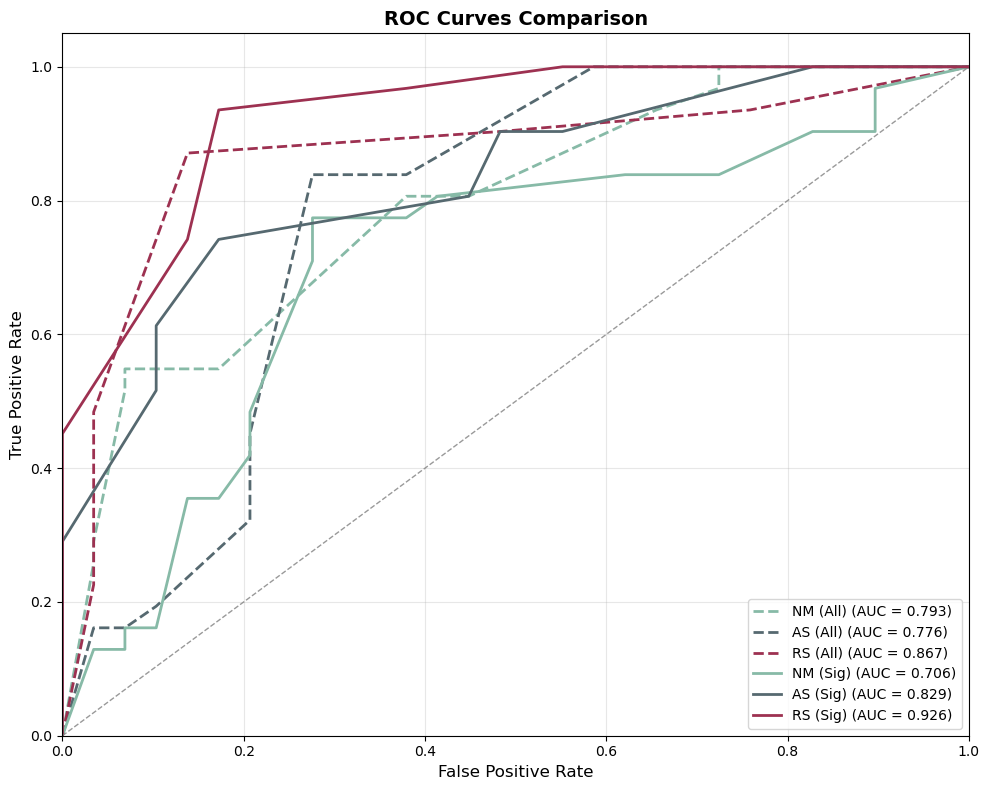

In [65]:
fig = plot_multi_model_roc(pred_hist)